In [ ]:
import numpy as np        # math/arrays - you need this for ML later
import pandas as pd       # dataframes - how you load and work with the CSV data
import matplotlib.pyplot as plt   # plotting graphs
import seaborn as sns     # nicer looking graphs, built on matplotlib
%matplotlib inline        
sns.set()                

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# just silences annoying warning messages in the output, not important

In [ ]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

# Part 1: Exploratory Data Analysis

In [ ]:
df_train.head() # Shows the first 5 pasengers adn all information of train csv

In [ ]:
df_train.info() # Shows data type and contraints of schema of train csv


In [ ]:
df_test.head() # Shows the first 5 pasengers adn all information of test csv

In [ ]:
df_test.info() # Shows data type and contraints of schema of test csv

In [ ]:
df_train.describe()

In [ ]:
df_test.describe()

### **Of all passengers in df_train, how many survived, how many died?**

In [ ]:
sns.countplot(x='Survived', data=df_train);

In [ ]:
print(df_train.Survived.sum()/df_train.Survived.count())

more people died than survived (38% survived)

-> base model : no survivors

submission : 0.627 accuracy

### **Sex: Female more likely to survive than male**

In [ ]:
df_train.groupby(['Survived','Sex'])['Survived'].count()

In [ ]:
sns.catplot(x='Sex', col='Survived', kind='count', data=df_train);

In [ ]:
print("% of women survived: " , round(df_train[df_train.Sex == 'female'].Survived.sum()/df_train[df_train.Sex == 'female'].Survived.count(), 4))
print("% of men survived:   " , round(df_train[df_train.Sex == 'male'].Survived.sum()/df_train[df_train.Sex == 'male'].Survived.count(), 4))

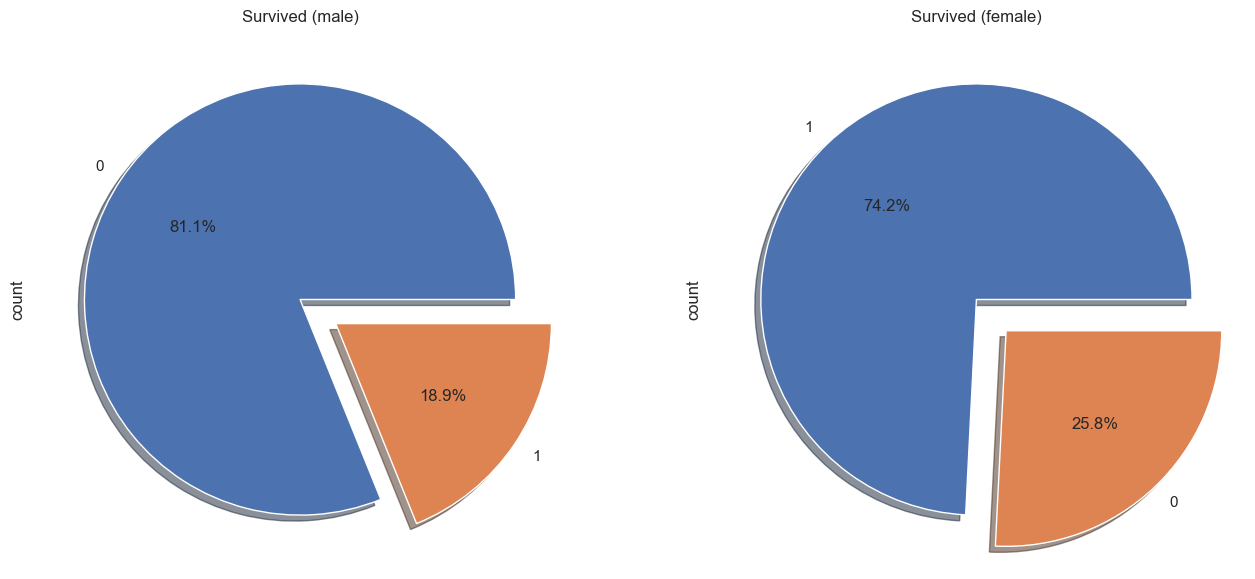

In [60]:
f,ax=plt.subplots(1,2,figsize=(16,7))
df_train['Survived'][df_train['Sex']=='male'].value_counts().plot.pie(explode=[0,0.2],autopct='%1.1f%%',ax=ax[0],shadow=True)
df_train['Survived'][df_train['Sex']=='female'].value_counts().plot.pie(explode=[0,0.2],autopct='%1.1f%%',ax=ax[1],shadow=True)
ax[0].set_title('Survived (male)')
ax[1].set_title('Survived (female)')

plt.show()

Women were more likely to survive than men

74 % of women survived but only 19% of men (in training set)

-> second model : all women survived and all men died

submission : 0.766 accuracy